In [14]:
%load_ext dotenv
%dotenv 
import os
import sys
sys.path.append(os.getenv('SRC_DIR'))
from logger import get_logger
_logs = get_logger(__name__)

The dotenv extension is already loaded. To reload it, use:
  %reload_ext dotenv


In [15]:
import dask.dataframe as dd
import pandas as pd
import numpy as np
import os
from glob import glob

In [6]:
ft_dir = os.getenv("FEATURES_DATA")
ft_dir + '/*.parquet'
os.path.join(ft_dir, '/*.parquet') # another way 
os.path.join(ft_dir, '*.parquet') # remove '/' as it used for different other action '\n' and it's characte return, 
#'\b' as indicator for word and many other
# if want to write backslash it need to be written as "\\" that is the reason why python has double slashes

'../../05_src/data/features/stock_features.parquet\\*.parquet'

In [16]:
ft_dir = os.getenv("FEATURES_DATA")
ft_glob = glob(ft_dir+'/*.parquet')
ft_glob # collection of different files that has indicate

['../../05_src/data/features/stock_features.parquet\\part.0.parquet',
 '../../05_src/data/features/stock_features.parquet\\part.1.parquet',
 '../../05_src/data/features/stock_features.parquet\\part.10.parquet',
 '../../05_src/data/features/stock_features.parquet\\part.100.parquet',
 '../../05_src/data/features/stock_features.parquet\\part.1000.parquet',
 '../../05_src/data/features/stock_features.parquet\\part.10000.parquet',
 '../../05_src/data/features/stock_features.parquet\\part.10001.parquet',
 '../../05_src/data/features/stock_features.parquet\\part.10002.parquet',
 '../../05_src/data/features/stock_features.parquet\\part.10003.parquet',
 '../../05_src/data/features/stock_features.parquet\\part.10004.parquet',
 '../../05_src/data/features/stock_features.parquet\\part.10005.parquet',
 '../../05_src/data/features/stock_features.parquet\\part.10006.parquet',
 '../../05_src/data/features/stock_features.parquet\\part.10007.parquet',
 '../../05_src/data/features/stock_features.parquet\

In [17]:

df = dd.read_parquet(ft_glob).compute().reset_index() # remove and reset the index

In [20]:
df

Price,Ticker,Date,Adj Close,Close,High,Low,Open,Volume,Year,Close_lag_1
0,DOV,2025-01-02 00:00:00+00:00,185.639999,185.639999,189.000000,184.929993,188.320007,651800.0,2025,NaN
1,DOV,2025-01-03 00:00:00+00:00,188.029999,188.029999,188.470001,185.160004,186.660004,404500.0,2025,185.639999
2,DOV,2025-01-06 00:00:00+00:00,188.029999,188.029999,190.300003,187.479996,188.000000,453600.0,2025,188.029999
3,DOV,2025-01-07 00:00:00+00:00,187.979996,187.979996,189.199997,186.869995,187.910004,692500.0,2025,188.029999
4,DOV,2025-01-08 00:00:00+00:00,187.220001,187.220001,187.850006,185.509995,187.009995,653200.0,2025,187.979996
...,...,...,...,...,...,...,...,...,...,...
3172919,CTLT,2021-12-27 00:00:00+00:00,126.360001,126.360001,127.300003,124.949997,125.900002,452316.0,2021,124.959999
3172920,CTLT,2021-12-28 00:00:00+00:00,125.360001,125.360001,127.000000,125.055000,125.930000,335608.0,2021,126.360001
3172921,CTLT,2021-12-29 00:00:00+00:00,128.080002,128.080002,128.520004,124.309998,125.059998,715711.0,2021,125.360001
3172922,CTLT,2021-12-30 00:00:00+00:00,128.509995,128.509995,129.729996,127.760002,128.750000,378368.0,2021,128.080002


In [21]:
df['Ticker']

0           DOV
1           DOV
2           DOV
3           DOV
4           DOV
           ... 
3172919    CTLT
3172920    CTLT
3172921    CTLT
3172922    CTLT
3172923    CTLT
Name: Ticker, Length: 3172924, dtype: object

In [22]:
type(df['Ticker']) # determine the type of objects (it's series here)

pandas.core.series.Series

In [23]:
df.info() # useful information about the datase, size(230.0mb)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3172924 entries, 0 to 3172923
Data columns (total 10 columns):
 #   Column       Dtype              
---  ------       -----              
 0   Ticker       object             
 1   Date         datetime64[ns, UTC]
 2   Adj Close    float64            
 3   Close        float64            
 4   High         float64            
 5   Low          float64            
 6   Open         float64            
 7   Volume       float64            
 8   Year         int32              
 9   Close_lag_1  float64            
dtypes: datetime64[ns, UTC](1), float64(7), int32(1), object(1)
memory usage: 230.0+ MB


In [25]:

df['Ticker'].unique()

array(['DOV', 'CBRE', 'FANG', 'DTE', 'AOS', 'BDX', 'BA', 'KEY', 'BXP',
       'INCY', 'ORLY', 'BRO', 'CTVA', 'MCO', 'REG', 'FITB', 'RTX', 'FSLR',
       'HAS', 'ZBH', 'HWM', 'RL', 'APA', 'HSY', 'LDOS', 'MRNA', 'ECL',
       'BF.B', 'FLT', 'PFE', 'BIIB', 'FOXA', 'PNW', 'STZ', 'INTU', 'AEE',
       'SNPS', 'GWW', 'LH', 'IBM', 'TFX', 'CCL', 'WM', 'VZ', 'DFS', 'FDX',
       'VRSK', 'UHS', 'PARA', 'XEL', 'FOX', 'ZTS', 'CTSH', 'AAL', 'AIG',
       'BR', 'EL', 'JNJ', 'LIN', 'EQR', 'MTCH', 'EOG', 'CCI', 'WST',
       'HAL', 'MOH', 'NKE', 'KMB', 'TDY', 'TMUS', 'KLAC', 'MSCI', 'TAP',
       'GPN', 'MCK', 'AES', 'JCI', 'TDG', 'VLO', 'CAH', 'GM', 'ED', 'SNA',
       'DOW', 'CMA', 'TRMB', 'DE', 'GE', 'LHX', 'META', 'CEG', 'AMP',
       'MCHP', 'AEP', 'KMI', 'TSN', 'PEAK', 'UNH', 'TRGP', 'IDXX', 'PFG',
       'GRMN', 'MOS', 'IFF', 'MO', 'ETSY', 'HSIC', 'AME', 'IQV', 'INVH',
       'MRK', 'EW', 'PM', 'ANSS', 'TROW', 'ABBV', 'EXPD', 'MAA', 'D',
       'PSA', 'CRM', 'EG', 'XRAY', 'WFC', 'MHK', 'KEYS', 

In [26]:
#ft_dir = os.getenv("FEATURES_DATA")
ft_dir = '../../05_src/data/features/stock_features'
df = dd.read_parquet(ft_glob).compute().reset_index()

In [26]:
df['Ticker'].unique()

array(['DOV', 'CBRE', 'FANG', 'DTE', 'AOS', 'BDX', 'BA', 'KEY', 'BXP',
       'INCY', 'ORLY', 'BRO', 'CTVA', 'MCO', 'REG', 'FITB', 'RTX', 'FSLR',
       'HAS', 'ZBH', 'HWM', 'RL', 'APA', 'HSY', 'LDOS', 'MRNA', 'ECL',
       'BF.B', 'FLT', 'PFE', 'BIIB', 'FOXA', 'PNW', 'STZ', 'INTU', 'AEE',
       'SNPS', 'GWW', 'LH', 'IBM', 'TFX', 'CCL', 'WM', 'VZ', 'DFS', 'FDX',
       'VRSK', 'UHS', 'PARA', 'XEL', 'FOX', 'ZTS', 'CTSH', 'AAL', 'AIG',
       'BR', 'EL', 'JNJ', 'LIN', 'EQR', 'MTCH', 'EOG', 'CCI', 'WST',
       'HAL', 'MOH', 'NKE', 'KMB', 'TDY', 'TMUS', 'KLAC', 'MSCI', 'TAP',
       'GPN', 'MCK', 'AES', 'JCI', 'TDG', 'VLO', 'CAH', 'GM', 'ED', 'SNA',
       'DOW', 'CMA', 'TRMB', 'DE', 'GE', 'LHX', 'META', 'CEG', 'AMP',
       'MCHP', 'AEP', 'KMI', 'TSN', 'PEAK', 'UNH', 'TRGP', 'IDXX', 'PFG',
       'GRMN', 'MOS', 'IFF', 'MO', 'ETSY', 'HSIC', 'AME', 'IQV', 'INVH',
       'MRK', 'EW', 'PM', 'ANSS', 'TROW', 'ABBV', 'EXPD', 'MAA', 'D',
       'PSA', 'CRM', 'EG', 'XRAY', 'WFC', 'MHK', 'KEYS', 

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3172924 entries, 0 to 3172923
Data columns (total 10 columns):
 #   Column       Dtype              
---  ------       -----              
 0   Ticker       object             
 1   Date         datetime64[ns, UTC]
 2   Adj Close    float64            
 3   Close        float64            
 4   High         float64            
 5   Low          float64            
 6   Open         float64            
 7   Volume       float64            
 8   Year         int32              
 9   Close_lag_1  float64            
dtypes: datetime64[ns, UTC](1), float64(7), int32(1), object(1)
memory usage: 230.0+ MB


In [25]:
df['Ticker'].unique()

array(['DOV', 'CBRE', 'FANG', 'DTE', 'AOS', 'BDX', 'BA', 'KEY', 'BXP',
       'INCY', 'ORLY', 'BRO', 'CTVA', 'MCO', 'REG', 'FITB', 'RTX', 'FSLR',
       'HAS', 'ZBH', 'HWM', 'RL', 'APA', 'HSY', 'LDOS', 'MRNA', 'ECL',
       'BF.B', 'FLT', 'PFE', 'BIIB', 'FOXA', 'PNW', 'STZ', 'INTU', 'AEE',
       'SNPS', 'GWW', 'LH', 'IBM', 'TFX', 'CCL', 'WM', 'VZ', 'DFS', 'FDX',
       'VRSK', 'UHS', 'PARA', 'XEL', 'FOX', 'ZTS', 'CTSH', 'AAL', 'AIG',
       'BR', 'EL', 'JNJ', 'LIN', 'EQR', 'MTCH', 'EOG', 'CCI', 'WST',
       'HAL', 'MOH', 'NKE', 'KMB', 'TDY', 'TMUS', 'KLAC', 'MSCI', 'TAP',
       'GPN', 'MCK', 'AES', 'JCI', 'TDG', 'VLO', 'CAH', 'GM', 'ED', 'SNA',
       'DOW', 'CMA', 'TRMB', 'DE', 'GE', 'LHX', 'META', 'CEG', 'AMP',
       'MCHP', 'AEP', 'KMI', 'TSN', 'PEAK', 'UNH', 'TRGP', 'IDXX', 'PFG',
       'GRMN', 'MOS', 'IFF', 'MO', 'ETSY', 'HSIC', 'AME', 'IQV', 'INVH',
       'MRK', 'EW', 'PM', 'ANSS', 'TROW', 'ABBV', 'EXPD', 'MAA', 'D',
       'PSA', 'CRM', 'EG', 'XRAY', 'WFC', 'MHK', 'KEYS', 

# Sampling in Python

+ There are different packages that allow sampling.
+ A practical approach is to use pandas/Dask sampling methods.

## Random Sampling

+ Sample n rows from a dataframe with [`df.sample()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sample.html).

```
DataFrame.sample(
    n=None, frac=None, replace=False, weights=None, 
    random_state=None, axis=None, ignore_index=False
    )
```

In [41]:
df.sample(n = 5, random_state =  42)

Price,Ticker,Date,Adj Close,Close,High,Low,Open,Volume,Year,Close_lag_1
2292001,BLK,2003-08-29 00:00:00+00:00,27.769110,45.470001,45.619999,45.040001,45.360001,36400.0,2003,45.360001
2494529,PEP,2007-05-24 00:00:00+00:00,40.991791,68.449997,69.059998,68.370003,68.739998,6077800.0,2007,68.690002
1641890,AXP,2007-03-09 00:00:00+00:00,43.029995,56.900002,57.349998,56.549999,57.070000,3819800.0,2007,56.820000
376966,EQR,2007-12-20 00:00:00+00:00,16.554724,36.020000,37.000000,35.320000,36.540001,2715400.0,2007,36.860001
777565,WFC,2015-09-10 00:00:00+00:00,40.216724,52.560001,52.860001,51.799999,52.070000,17996200.0,2015,52.189999


In [43]:
df['Ticker'].unique()

array(['DOV', 'CBRE', 'FANG', 'DTE', 'AOS', 'BDX', 'BA', 'KEY', 'BXP',
       'INCY', 'ORLY', 'BRO', 'CTVA', 'MCO', 'REG', 'FITB', 'RTX', 'FSLR',
       'HAS', 'ZBH', 'HWM', 'RL', 'APA', 'HSY', 'LDOS', 'MRNA', 'ECL',
       'BF.B', 'FLT', 'PFE', 'BIIB', 'FOXA', 'PNW', 'STZ', 'INTU', 'AEE',
       'SNPS', 'GWW', 'LH', 'IBM', 'TFX', 'CCL', 'WM', 'VZ', 'DFS', 'FDX',
       'VRSK', 'UHS', 'PARA', 'XEL', 'FOX', 'ZTS', 'CTSH', 'AAL', 'AIG',
       'BR', 'EL', 'JNJ', 'LIN', 'EQR', 'MTCH', 'EOG', 'CCI', 'WST',
       'HAL', 'MOH', 'NKE', 'KMB', 'TDY', 'TMUS', 'KLAC', 'MSCI', 'TAP',
       'GPN', 'MCK', 'AES', 'JCI', 'TDG', 'VLO', 'CAH', 'GM', 'ED', 'SNA',
       'DOW', 'CMA', 'TRMB', 'DE', 'GE', 'LHX', 'META', 'CEG', 'AMP',
       'MCHP', 'AEP', 'KMI', 'TSN', 'PEAK', 'UNH', 'TRGP', 'IDXX', 'PFG',
       'GRMN', 'MOS', 'IFF', 'MO', 'ETSY', 'HSIC', 'AME', 'IQV', 'INVH',
       'MRK', 'EW', 'PM', 'ANSS', 'TROW', 'ABBV', 'EXPD', 'MAA', 'D',
       'PSA', 'CRM', 'EG', 'XRAY', 'WFC', 'MHK', 'KEYS', 

In [67]:
select_tickers = df['Ticker'].unique().tolist()[0:9]
select_tickers

['DOV', 'CBRE', 'FANG', 'DTE', 'AOS', 'BDX', 'BA', 'KEY', 'BXP']

In [44]:
# select_tickers = df['ticker'].unique().tolist()[0:9]
select_tickers = ['OXY', 'TXN', 'PCG', 'CBRE', 'ROK', 'AMT', 'D', 'YUM', 'PWR']
select_tickers

['OXY', 'TXN', 'PCG', 'CBRE', 'ROK', 'AMT', 'D', 'YUM', 'PWR']

In [45]:
type(select_tickers)

list

In [45]:
idx = df['Ticker'].isin(select_tickers)
idx


0          False
1          False
2          False
3          False
4          False
           ...  
3172919    False
3172920    False
3172921    False
3172922    False
3172923    False
Name: Ticker, Length: 3172924, dtype: bool

In [49]:
sum(idx)

56772

In [46]:
idx = df['Ticker'].isin(select_tickers) 
small_df =  df[idx]
#small_df # 56772 row X 10 columns

simple_sample_dt = small_df.sample(frac = 0.1)
#simple_sample_dt  # small dataframe with 10% of small_df
simple_sample_dt.shape, small_df.shape # return the compare of two sizes (5677, 10) for simple_sample_dt, (56772, 10) for small_df


((5677, 10), (56772, 10))

Look at the distribution of tickers.

<Axes: xlabel='Ticker'>

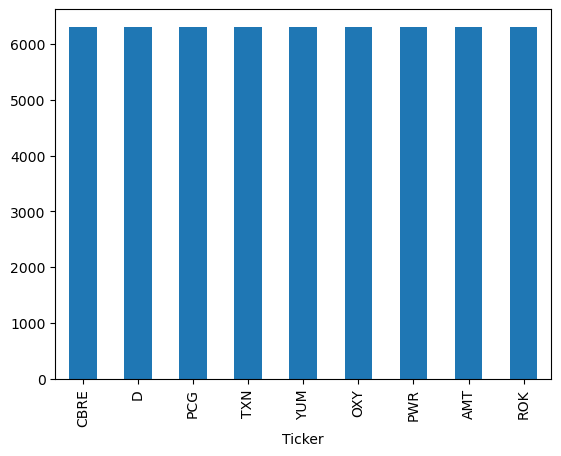

In [50]:
small_df['Ticker']#.value_counts()#.plot(kind='bar')
small_df['Ticker'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

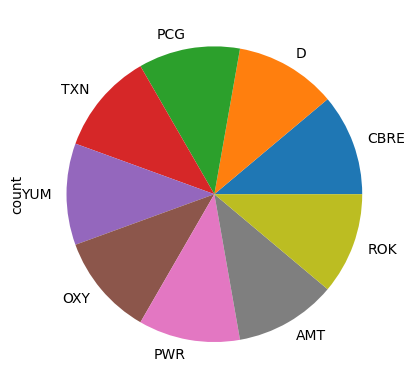

In [61]:
small_df['Ticker'].value_counts().plot(kind='pie')

In [ ]:
histogram is not a valid plot kind Valid plot kinds: ('line', 'bar', 'barh', 'kde', 'density', 'area', 'hist', 'box', 'pie', 'scatter', 'hexbin'

<Axes: xlabel='Ticker'>

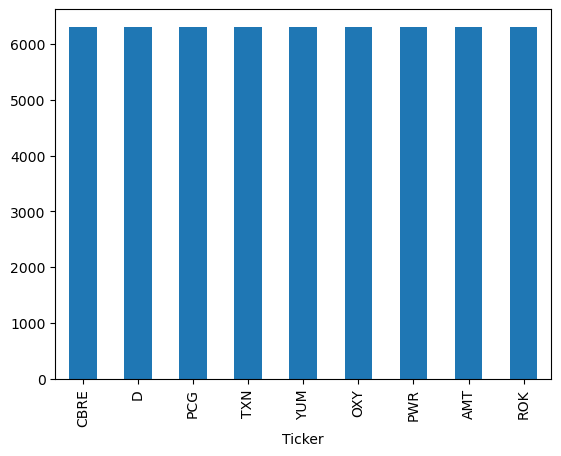

In [60]:
small_df['Ticker'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

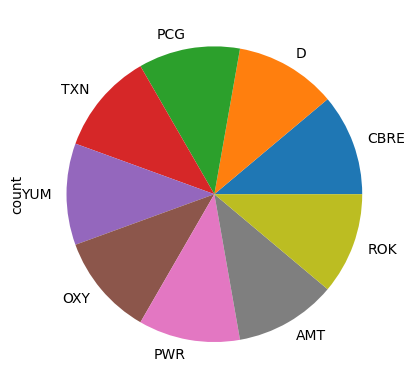

In [62]:
small_df['Ticker'].value_counts().plot(kind='pie')

In [63]:
simple_sample_dt['Ticker'].value_counts()#.plot(kind='bar')

Ticker
OXY     692
ROK     649
PWR     643
YUM     642
CBRE    637
PCG     621
TXN     615
AMT     598
D       580
Name: count, dtype: int64

<Axes: ylabel='count'>

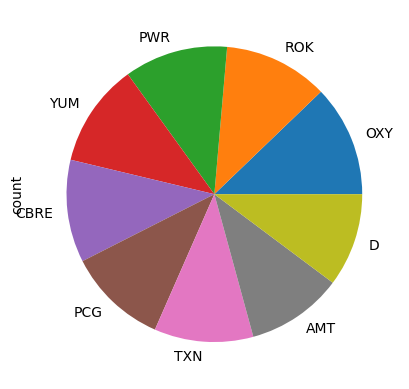

In [64]:
simple_sample_dt['Ticker'].value_counts().plot(kind='pie')

<Axes: xlabel='Ticker'>

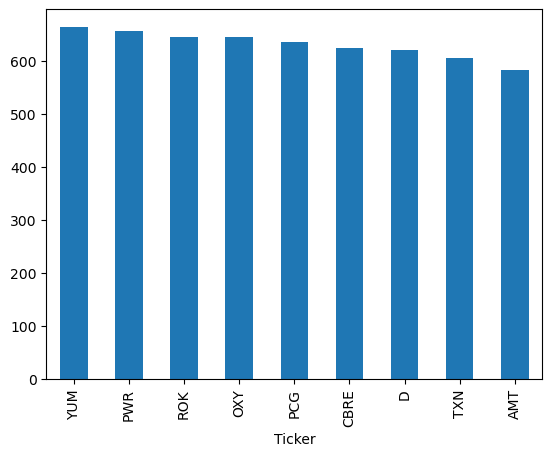

In [63]:
simple_sample_dt['Ticker'].value_counts().plot(kind='bar')

## Stratified Sampling

+ Use `groupby()` and `.sample()` for stratified sampling.

In [ ]:
small_df['Ticker'].value_counts().plot(kind='bar')


simple_sample_dt = small_df.sample(frac = 0.1)
simple_sample_dt['Ticker'].value_counts().plot(kind='bar')


strat_sample_dt = small_df.groupby(['Ticker']).sample(frac = 0.1)
strat_sample_dt['Ticker'].value_counts().plot(kind='bar')

<Axes: xlabel='Ticker'>

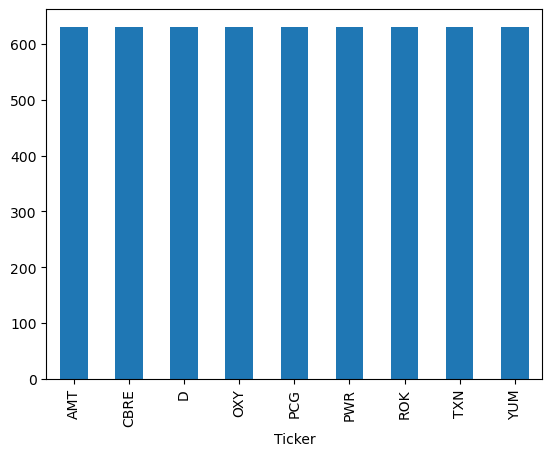

In [68]:
strat_sample_dt = small_df.groupby(['Ticker']).sample(frac = 0.1)
strat_sample_dt['Ticker'].value_counts().plot(kind='bar')
#strat_sample_dt 

# Sampling in Dask

+ Stratified sampling in `dask` can be achieved with `groupby().apply()` and a lambda function.

C:\Users\User\AppData\Local\Temp\ipykernel_6188\2388710987.py:2: UserWarning: `meta` is not specified, inferred from partial data. Please provide `meta` if the result is unexpected.
  Before: .apply(func)
  After:  .apply(func, meta={'x': 'f8', 'y': 'f8'}) for dataframe result
  or:     .apply(func, meta=('x', 'f8'))            for series result
  strat_sample_dd_dt = (dd_dt


<Axes: xlabel='Ticker'>

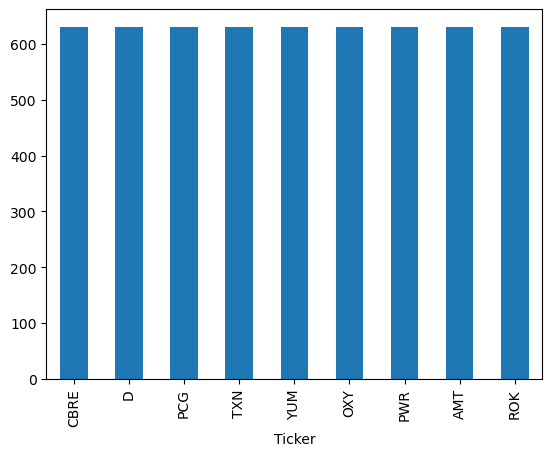

In [69]:
dd_dt = dd.read_parquet(ft_glob)
strat_sample_dd_dt = (dd_dt
                      .groupby('Ticker', group_keys=False)
                      .apply(lambda x: x.sample(frac = 0.1))
                      .compute()
                      .reset_index())
strat_sample_dd_dt[strat_sample_dd_dt['Ticker'].isin(select_tickers)]['Ticker'].value_counts().plot(kind='bar')